# Sensor Fusion, seen — two sensors, one belief

By the end of this notebook you will *see*:

1. **where measurements come from** — a real object detector on a real camera,
2. **the Kalman filter itself** — predict then correct, written out and stepped through here,
3. **fusion working** — lidar + radar folded into one moving estimate, on real nuScenes data.

No black boxes: the filter is in this notebook, not hidden in a library.


## Setup


In [1]:
# --- Colab setup (idempotent + cache-safe) ---
import os, sys
BRANCH = 'claude/course-modernization-review-x6ytmr'
if os.path.isdir('/content'):
    os.system('cd /content && rm -rf kalman_filters_course && '
              f'git clone --branch {BRANCH} https://github.com/Jeremy26/kalman_filters_course.git')
    os.chdir('/content/kalman_filters_course/ekf_sensor_fusion')
    os.system('pip install -q numpy matplotlib ultralytics')
for _m in [m for m in list(sys.modules) if 'kf_fusion' in m]:
    del sys.modules[_m]
sys.path.insert(0, 'src')
import numpy as np, matplotlib.pyplot as plt
from kf_fusion import load_track
print('setup OK')


setup OK


## Step 1 — Perception: where does a measurement come from?

A tracker doesn't get coordinates for free. Something has to **detect** the object first. Here's a real object detector (YOLO) on a real camera frame from the scene. The green box is the car we'll track; the yellow boxes are other detections (real clutter).


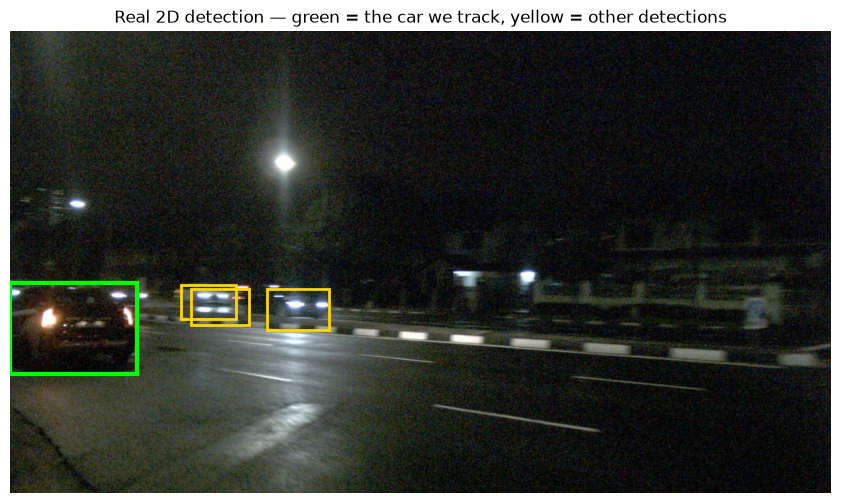

In [2]:
import json
from ultralytics import YOLO
from kf_fusion.detection import ensure_yolo_weights
yolo = YOLO(ensure_yolo_weights())            # weights auto-download from Hugging Face
tgt = json.load(open('data/sample_frames/target_boxes.json'))['frame_0']['target_box']
img = 'data/sample_frames/frame_0.jpg'
res = yolo(img, verbose=False, classes=[2,5,7])[0]   # cars/buses/trucks

im = plt.imread(img); fig, ax = plt.subplots(figsize=(11,6)); ax.imshow(im); ax.axis('off')
def draw(b, color, lw=2):
    ax.add_patch(plt.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1], fill=False, color=color, lw=lw))
tc = [(tgt[0]+tgt[2])/2, (tgt[1]+tgt[3])/2]
for box in res.boxes.xyxy.cpu().numpy():
    is_target = box[0] <= tc[0] <= box[2] and box[1] <= tc[1] <= box[3]
    draw(box, 'lime' if is_target else 'gold', 3 if is_target else 2)
ax.set_title('Real 2D detection — green = the car we track, yellow = other detections')
plt.show()


That detection, done every frame by lidar and radar, is the **input** to the filter. Let's look at those raw measurements for our car over ~20 seconds of real driving.


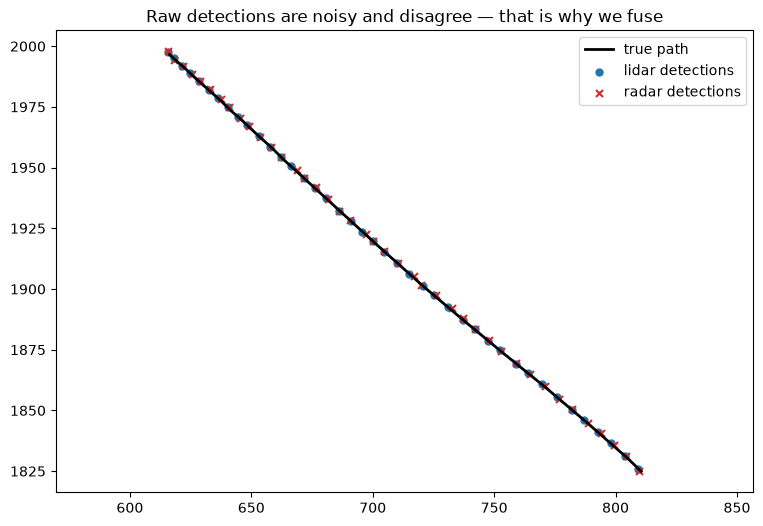

In [3]:
track = load_track('data/track_ed634e83.npz')
lidar = np.array([m.z[:2] for m in track.measurements if m.sensor=='lidar'])
# radar measures range/bearing about the moving ego -> convert to x,y just to plot it
radar = np.array([[m.sensor_pos[0]+m.z[0]*np.cos(m.z[1]), m.sensor_pos[1]+m.z[0]*np.sin(m.z[1])]
                  for m in track.measurements if m.sensor=='radar'])
gt = track.gt_state[:, :2]
plt.figure(figsize=(9,6))
plt.plot(gt[:,0], gt[:,1], 'k-', lw=2, label='true path')
plt.scatter(lidar[:,0], lidar[:,1], c='tab:blue', s=25, label='lidar detections')
plt.scatter(radar[:,0], radar[:,1], c='tab:red', s=25, marker='x', label='radar detections')
plt.axis('equal'); plt.legend(); plt.title('Raw detections are noisy and disagree — that is why we fuse'); plt.show()


## Step 2 — The Kalman filter, written out

The state is the car's position **and velocity**: `x = [px, py, vx, vy]`.

Two moves, forever:

- **predict** — push the state forward with constant velocity; uncertainty `P` **grows**.
- **update** — a measurement pulls the state back; uncertainty `P` **shrinks**.

Fusion is just: *update from whichever sensor spoke.* Lidar updates position; radar updates position **and** velocity (Doppler). Same state, two sources. Here is the whole filter — read it.


In [4]:
class TinyEKF:
    def __init__(self, noise_a=4.0):
        self.x = np.zeros(4); self.P = np.eye(4); self.q = noise_a

    def predict(self, dt):
        F = np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]], float)
        g = np.array([0.5*dt*dt, 0.5*dt*dt, dt, dt])
        Q = np.outer(g, g) * self.q                 # process noise from acceleration
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q               # <-- uncertainty GROWS

    def _update(self, y, H, R):
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)         # Kalman gain: trust measurement vs prediction
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ H) @ self.P       # <-- uncertainty SHRINKS

    def update_lidar(self, z):                      # z = [px, py] (linear)
        H = np.array([[1,0,0,0],[0,1,0,0]], float)
        self._update(z - H @ self.x, H, np.diag([1.0, 1.0]))

    def update_radar(self, z, s):                   # z = [range, bearing, range-rate] about sensor s
        px,py,vx,vy = self.x; dx,dy = px-s[0], py-s[1]
        rho = max(np.hypot(dx,dy), 1e-6)
        h = np.array([rho, np.arctan2(dy,dx), (dx*vx+dy*vy)/rho])   # nonlinear -> the 'Extended' bit
        H = np.array([[dx/rho, dy/rho, 0, 0],
                      [-dy/rho**2, dx/rho**2, 0, 0],
                      [dy*(vx*dy-vy*dx)/rho**3, dx*(vy*dx-vx*dy)/rho**3, dx/rho, dy/rho]])
        y = z - h; y[1] = (y[1]+np.pi)%(2*np.pi) - np.pi            # wrap the angle
        self._update(y, H, np.diag([0.5, 0.01, 4.0]))
print('TinyEKF defined — that is the entire filter')


TinyEKF defined — that is the entire filter


### See one predict and one update
Watch the position uncertainty (the ellipse) balloon on **predict**, then snap tight on **update**.


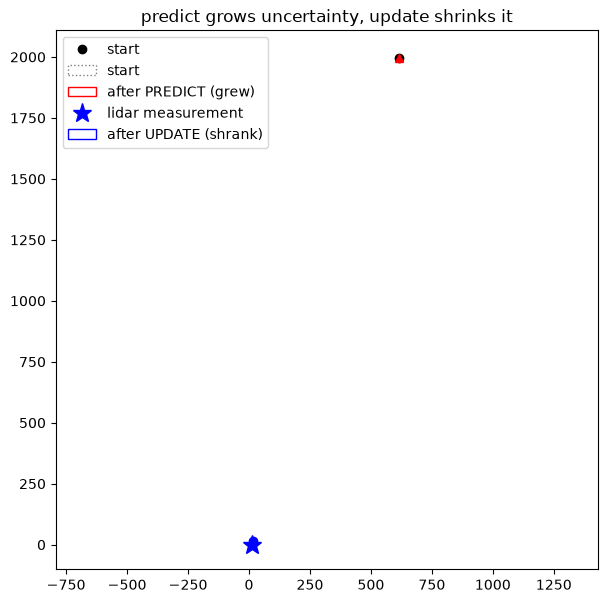

In [5]:
def ellipse(P, xy, **kw):
    vals, vecs = np.linalg.eigh(P[:2,:2]); ang = np.degrees(np.arctan2(*vecs[:,1][::-1]))
    from matplotlib.patches import Ellipse
    return Ellipse(xy, 2*np.sqrt(vals[0]), 2*np.sqrt(vals[1]), angle=ang, fill=False, **kw)

kf = TinyEKF(); m0 = track.measurements[0]
kf.x = np.array([m0.z[0], m0.z[1], 0, 0.]); kf.P = np.diag([2,2,25,25.])
fig, ax = plt.subplots(figsize=(7,7)); ax.plot(*kf.x[:2], 'ko', label='start')
ax.add_patch(ellipse(kf.P, kf.x[:2], color='gray', ls=':', label='start'))
kf.predict(2.0)
ax.plot(*kf.x[:2], 'r^'); ax.add_patch(ellipse(kf.P, kf.x[:2], color='red', label='after PREDICT (grew)'))
z = track.measurements[2].z[:2]; ax.plot(*z, 'b*', ms=14, label='lidar measurement')
kf.update_lidar(z)
ax.plot(*kf.x[:2], 'bo'); ax.add_patch(ellipse(kf.P, kf.x[:2], color='blue', label='after UPDATE (shrank)'))
ax.axis('equal'); ax.legend(); ax.set_title('predict grows uncertainty, update shrinks it'); plt.show()


## Step 3 — Fuse the whole track, and watch it work

Now run that same filter across every measurement: predict to each timestamp, then update with lidar or radar. The smooth line is the fused estimate riding through the noisy detections.


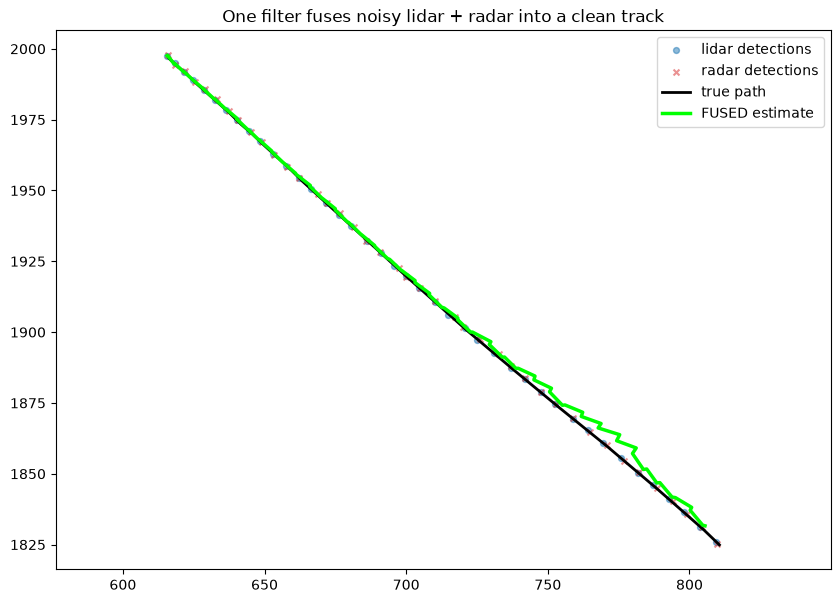

In [6]:
def run(measurements, use_lidar=True, use_radar=True):
    kf = TinyEKF(); est = []; last = None; started = False
    for m in measurements:
        if not started:
            kf.x = np.concatenate([m.initial_state()[:2], [0,0]]); kf.P = np.diag([2,2,25,25.])
            last = m.timestamp; started = True
        else:
            kf.predict(m.timestamp - last); last = m.timestamp
            if m.sensor=='lidar' and use_lidar: kf.update_lidar(m.z)
            if m.sensor=='radar' and use_radar: kf.update_radar(m.z, m.sensor_pos)
        est.append(kf.x.copy())
    return np.array(est)

est = run(track.measurements)
plt.figure(figsize=(10,7))
plt.scatter(lidar[:,0], lidar[:,1], c='tab:blue', s=18, alpha=.5, label='lidar detections')
plt.scatter(radar[:,0], radar[:,1], c='tab:red', s=18, alpha=.5, marker='x', label='radar detections')
plt.plot(gt[:,0], gt[:,1], 'k-', lw=2, label='true path')
plt.plot(est[:,0], est[:,1], 'lime', lw=2.5, label='FUSED estimate')
plt.axis('equal'); plt.legend(); plt.title('One filter fuses noisy lidar + radar into a clean track'); plt.show()


### Why bother with two sensors?
Lidar gives crisp position but no speed; radar's Doppler gives speed directly. Fusion gets both. Here's the **estimated speed** — flat and sensible only because radar is in the mix.


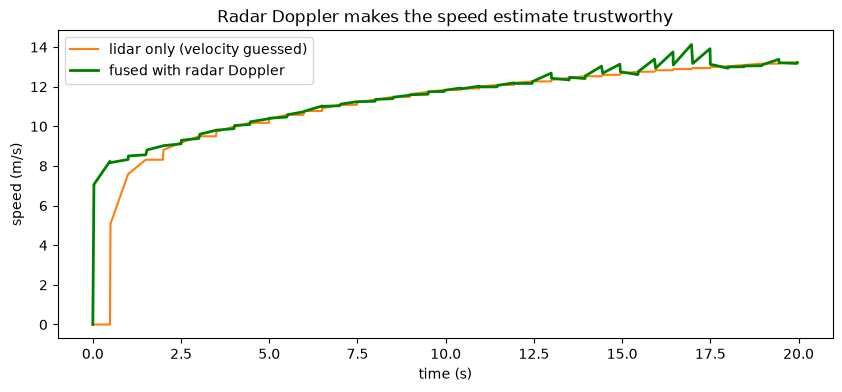

In [7]:
speed_fused = np.hypot(est[:,2], est[:,3])
speed_lidar = np.hypot(*run(track.measurements, use_radar=False)[:, 2:].T)
t = track.timestamps if hasattr(track,'timestamps') else np.arange(len(est))
tt = [m.timestamp for m in track.measurements]
plt.figure(figsize=(10,4))
plt.plot(tt, speed_lidar, 'tab:orange', label='lidar only (velocity guessed)')
plt.plot(tt, speed_fused, 'green', lw=2, label='fused with radar Doppler')
plt.xlabel('time (s)'); plt.ylabel('speed (m/s)'); plt.legend()
plt.title('Radar Doppler makes the speed estimate trustworthy'); plt.show()


## Step 4 — See it in the real 3D scene (Foxglove)

The plots above are the idea. The **full experience** — the camera with live detections, the real lidar point cloud, the radar returns, and the tracked box moving through it — is a Foxglove recording. Generate it (needs the dataset) or open the one shipped in `outputs/`:

1. go to [app.foxglove.dev](https://app.foxglove.dev) → **Open local file**,
2. choose `outputs/scene_ed634e83.mcap`,
3. **Import layout** → `layouts/scene.json`.

You'll see the camera (left) with detection boxes, and the 3D scene (right) with lidar, radar, and the fused box tracking the car. To regenerate it yourself:

```bash
pip install -e ".[viz,nuscenes]"
python scripts/download_nuscenes.py           # ~4 GB, one time
python scripts/make_scene_mcap.py --instance ed634e83 --out outputs/scene_ed634e83.mcap
```


## Recap

- **Detection** produces noisy measurements (you saw YOLO do it).
- The **Kalman filter** predicts, then corrects — you read the whole thing and stepped it.
- **Fusion** is just updating one shared state from lidar *and* radar; you watched it clean up the track and pin down the speed.

> Next: run *many* of these at once and you must decide which detection belongs to which car — that's data association, and the start of multi-object tracking.
